In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import os
import geopandas as gpd
import rioxarray
import hvplot.xarray 
import pandas as pd
import numpy as np

from rasterio.mask import mask
from concurrent.futures import ProcessPoolExecutor
import rasterio
import regionmask

/home/azureuser/miniconda3/envs/geo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# # !mkdir -p /inputs/CHIRPS
# !wget "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/daily/final/rnl/1981/chirps-v3.0.rnl.1981.01.01.tif"

In [3]:
path_shapefiles = Path('../caravan_shapefiles/camels')

In [4]:
gdf = gpd.read_file(path_shapefiles / 'camels_basin_shapes.shp')
gdf.head()

,gauge_id,geometry
0,camels_01013500,"MULTIPOLYGON (((-68.06259 47.17901, -68.06028 ..."
1,camels_01022500,"POLYGON ((-67.97836 44.6131, -67.98141 44.6143..."
2,camels_01030500,"MULTIPOLYGON (((-68.09162 46.11477, -68.08453 ..."
3,camels_01031500,"MULTIPOLYGON (((-69.31629 45.15325, -69.32144 ..."
4,camels_01047000,"POLYGON ((-70.10847 45.21669, -70.10609 45.213..."


In [5]:
gauge = "camels_02152100"

In [6]:
basin = gdf[gdf['gauge_id'] == gauge]
basin

,gauge_id,geometry
133,camels_02152100,"POLYGON ((-81.75412 35.6119, -81.75036 35.6103..."


In [7]:
ds = xr.open_dataset("/inputs/CHIRPS/chirps-v2.0.1989.days_p05.nc")
ds

getfattr: /inputs/CHIRPS/chirps-v2.0.1989.days_p05.nc: Operation not supported


<xarray.Dataset> Size: 21GB
Dimensions:    (latitude: 2000, longitude: 7200, time: 365)
Coordinates:
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time       (time) datetime64[ns] 3kB 1989-01-01 1989-01-02 ... 1989-12-31
Data variables:
    precip     (time, latitude, longitude) float32 21GB ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-11-20
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

In [8]:
precip = ds["precip"].isel(time=0)
precip

<xarray.DataArray 'precip' (latitude: 2000, longitude: 7200)> Size: 58MB
[14400000 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
    time       datetime64[ns] 8B 1989-01-01
Attributes:
    units:               mm/day
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           day
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0

In [9]:
precip = precip.where(precip != -9999, np.nan)

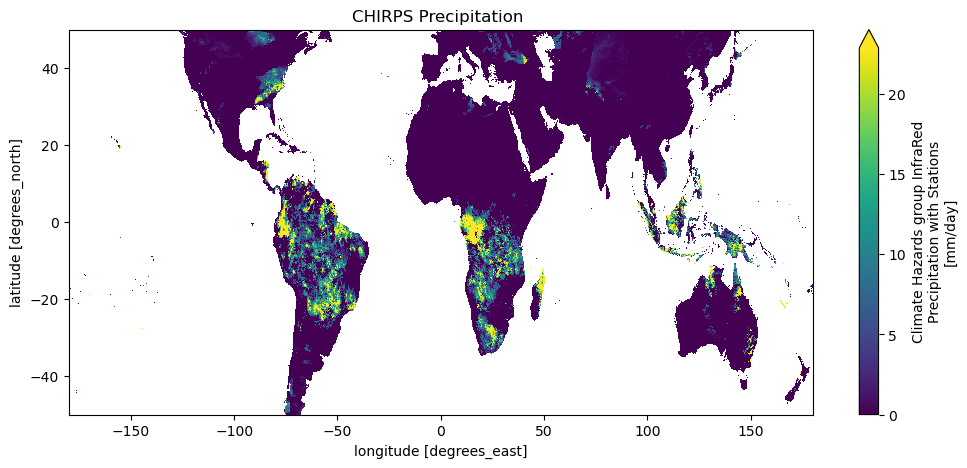

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(12,5))
precip.plot(
    ax=ax,
    x="longitude",
    y="latitude",
    cmap="viridis",
    # vmin=0, vmax=30,
    robust=True  # avoids extreme outliers messing up colors
)

# Use the filename or date from attributes since there is no time coordinate
ax.set_title(f"CHIRPS Precipitation {ds.attrs.get('TIFFTAG_DOCUMENTNAME','')}")
plt.show()

In [11]:
# Set the CRS on the DataArray (CHIRPS is in WGS84)
precip = precip.rio.write_crs("EPSG:4326")

# Make sure basin has the same CRS
basin = basin.to_crs("EPSG:4326")

# Clip
precip_clipped = precip.rio.clip(basin.geometry, basin.crs)
precip_clipped

<xarray.DataArray 'precip' (latitude: 2, longitude: 3)> Size: 24B
array([[1.7737503, 1.9140121, 2.4689949],
       [      nan, 1.853379 , 2.3933327]], dtype=float32)
Coordinates:
  * latitude     (latitude) float32 8B 35.52 35.57
  * longitude    (longitude) float32 12B -81.83 -81.78 -81.73
    time         datetime64[ns] 8B 1989-01-01
    spatial_ref  int64 8B 0
Attributes:
    units:               mm/day
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           day
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0

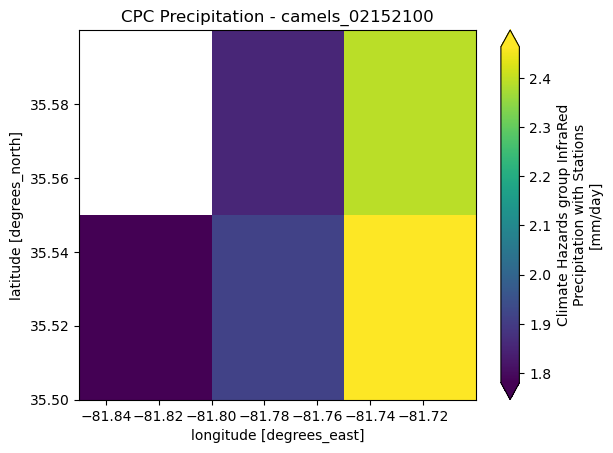

In [12]:
precip_clipped.plot(cmap="viridis", robust=True)
plt.title(f"CPC Precipitation - {gauge}")
plt.show()

# Creating the timeseries

In [ ]:
# def process_file(file_path, geometries, minx, miny, maxx, maxy):
#     ds = xr.open_dataset(file_path)
#     precip = ds["precip"].sel(
#         longitude=slice(minx - 0.2, maxx + 0.2),
#         latitude=slice(miny - 0.2, maxy + 0.2)
#     ).load()  # load only the small subset into RAM
    
#     precip = precip.where(precip != -9999, np.nan)
#     gdf_sub = gpd.GeoDataFrame(geometry=geometries, crs="EPSG:4326")
#     mask = regionmask.mask_geopandas(gdf_sub, precip.longitude, precip.latitude)
#     daily_mean = precip.where(mask == 0).mean(dim=("latitude", "longitude"))
    
#     ds.close()
#     return daily_mean.to_series()

def process_file(file_path, geometries, minx, miny, maxx, maxy):
    ds = xr.open_dataset(file_path)

    precip = ds["precip"].sel(
        longitude=slice(minx - 0.2, maxx + 0.2),
        latitude=slice(miny - 0.2, maxy + 0.2)
    ).load()

    # Replace missing values
    precip = precip.where(precip != -9999, np.nan)

    # Create mask
    gdf_sub = gpd.GeoDataFrame(geometry=geometries, crs="EPSG:4326")
    mask = regionmask.mask_geopandas(gdf_sub, precip.longitude, precip.latitude)

    precip_masked = precip.where(mask == 0)

    # --- AREA WEIGHTS ---
    weights = np.cos(np.deg2rad(precip_masked.latitude))
    weights = xr.DataArray(weights, coords={"latitude": precip_masked.latitude}, dims=("latitude",))

    # Normalize weights (optional but cleaner numerically)
    weights = weights / weights.mean()

    # Broadcast weights to match precip dimensions
    weights_2d = weights.broadcast_like(precip_masked.isel(time=0))

    # Apply weights
    weighted_sum = (precip_masked * weights_2d).sum(dim=("latitude", "longitude"))
    sum_of_weights = weights_2d.where(~np.isnan(precip_masked)).sum(dim=("latitude", "longitude"))

    daily_mean = weighted_sum / sum_of_weights

    ds.close()
    return daily_mean.to_series()


# --- Setup ---
chirps_files = sorted(Path("/inputs/CHIRPS/").glob("chirps-v2.0.*.days_p05.nc"))

gauge = "camels_02152100"
basin = gdf[gdf['gauge_id'] == gauge].to_crs("EPSG:4326")
geometries = list(basin.geometry)
minx, miny, maxx, maxy = basin.total_bounds

output_dir = Path('./precip_timeseries_chirpsv2')
output_dir.mkdir(exist_ok=True)

all_ts = []
for i, f in enumerate(chirps_files, 1):
    print(f"{gauge} - {f.stem} being processed ({i}/{len(chirps_files)})")
    ts = process_file(f, geometries, minx, miny, maxx, maxy)
    all_ts.append(ts)
    print(f"{gauge} - {f.stem} processed ({i}/{len(chirps_files)})")

# --- Build and save ---
full_ts = pd.concat(all_ts).sort_index()
full_ts.name = "precipitation"

output_file = output_dir / f"{gauge}_precip_new_process.csv"
full_ts.to_csv(output_file)
print(f"Saved {output_file}")

camels_02152100 - chirps-v2.0.1989.days_p05 being processed (1/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.1989.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.1989.days_p05 processed (1/31)
camels_02152100 - chirps-v2.0.1990.days_p05 being processed (2/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.1990.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.1990.days_p05 processed (2/31)
camels_02152100 - chirps-v2.0.1991.days_p05 being processed (3/31)


...

camels_02152100 - chirps-v2.0.2017.days_p05 processed (29/31)
camels_02152100 - chirps-v2.0.2018.days_p05 being processed (30/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.2018.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.2018.days_p05 processed (30/31)
camels_02152100 - chirps-v2.0.2019.days_p05 being processed (31/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.2019.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.2019.days_p05 processed (31/31)
Saved precip_timeseries_chirpsv2/camels_02152100_precip_new_process.csv


In [20]:
import exactextract
from exactextract import exact_extract

def process_file(file_path, gdf_sub, minx, miny, maxx, maxy):
    ds = xr.open_dataset(file_path)
    precip = ds["precip"].sel(
        longitude=slice(minx - 0.2, maxx + 0.2),
        latitude=slice(miny - 0.2, maxy + 0.2)
    ).load()  # load only the small subset into RAM

    precip = precip.where(precip != -9999, np.nan)

    # exact_extract "mean" uses pixel coverage fraction as weight automatically
    daily_means = []
    for t in range(len(precip.time)):
        da = precip.isel(time=t)
        result = exact_extract(da, gdf_sub, ["mean"], output="pandas")
        daily_means.append(result["mean"].values[0])

    times = precip.time.values
    ds.close()
    return pd.Series(daily_means, index=times)

# --- Setup ---
chirps_files = sorted(Path("/inputs/CHIRPS/").glob("chirps-v2.0.*.days_p05.nc"))

gauge = "camels_02152100"
basin = gdf[gdf['gauge_id'] == gauge].to_crs("EPSG:4326")
gdf_sub = gpd.GeoDataFrame(geometry=list(basin.geometry), crs="EPSG:4326")
minx, miny, maxx, maxy = basin.total_bounds

output_dir = Path('./precip_timeseries_chirpsv2')
output_dir.mkdir(exist_ok=True)

all_ts = []
for i, f in enumerate(chirps_files, 1):
    print(f"{gauge} - {f.stem} being processed ({i}/{len(chirps_files)})")
    ts = process_file(f, gdf_sub, minx, miny, maxx, maxy)
    all_ts.append(ts)
    print(f"{gauge} - {f.stem} processed ({i}/{len(chirps_files)})")

# --- Build and save ---
full_ts = pd.concat(all_ts).sort_index()
full_ts.name = "precipitation"

output_file = output_dir / f"{gauge}_precip_new_process.csv"
full_ts.to_csv(output_file)
print(f"Saved {output_file}")

camels_02152100 - chirps-v2.0.1989.days_p05 being processed (1/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.1989.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.1989.days_p05 processed (1/31)
camels_02152100 - chirps-v2.0.1990.days_p05 being processed (2/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.1990.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.1990.days_p05 processed (2/31)
camels_02152100 - chirps-v2.0.1991.days_p05 being processed (3/31)


...

camels_02152100 - chirps-v2.0.2017.days_p05 processed (29/31)
camels_02152100 - chirps-v2.0.2018.days_p05 being processed (30/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.2018.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.2018.days_p05 processed (30/31)
camels_02152100 - chirps-v2.0.2019.days_p05 being processed (31/31)


getfattr: /inputs/CHIRPS/chirps-v2.0.2019.days_p05.nc: Operation not supported


camels_02152100 - chirps-v2.0.2019.days_p05 processed (31/31)
Saved precip_timeseries_chirpsv2/camels_02152100_precip_new_process.csv
